In [14]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math
import time

In [3]:
# Utility functions

# A list of all bit strings of length n

def bit_strings(n):
    if n == 0:
        return [ [] ]
    else:
        bs = bit_strings(n-1)
        return list(map(lambda x: [0] + x, bs)) + list(map(lambda x: [1] + x, bs))

# A list of n zeroes with 1 in position m

def single_one(m,n):
    x = [0] * n
    x[m] = 1
    return x

# A list of n zeroes with -1 in position m

def single_minus_one(m,n):
    x = [0] * n
    x[m] = -1
    return x

# Working with n qubits, construct a unitary matrix from f

def unitary_from_function(f,n):
    u = []
    bs = bit_strings(n)
    for i in range(2**n):
        if f(bs[i]) == 1:
            u = u + [single_minus_one(i,2**n)]
        else:
            u = u + [single_one(i,2**n)]
    return u

w = [1, 1]

def f(x):
    if x == w:
        return 1
    else:
        return 0

# The Grover diffusion matrix for n qubits

def grover_row(r,n):
    N = 2**n
    row = []
    for i in range(r):
        row = row + [2.0/N]
    row = row + [2.0/N - 1]
    for i in range(r+1,N):
        row = row + [2.0/N]
    return row

def grover_diffusion(n):
    N = 2**n
    g = []
    for i in range(N):
        g = g + [grover_row(i,n)]
    return g

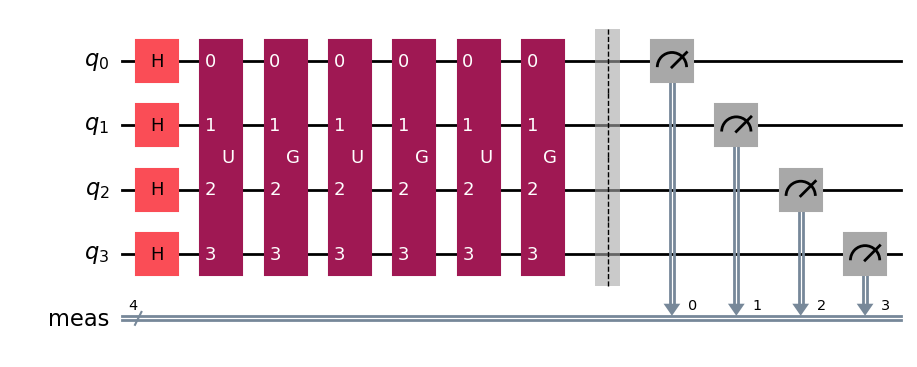

In [4]:
# Grover's algorithm with a parameteric construction of the circuit

# Given a function f : {0,1}^n -> {0,1} such that for some input vector w,
# f(w) = 1 and for all x != w, f(x) = 0.
# The problem is to find w.

# Define the number of qubits

n = 4

# Define f by setting the value of w

w = [0, 1, 0, 0] # length must be equal to n

def f(x):
    if x == w:
        return 1
    else:
        return 0

# Construct U which has -1 in the correct position on the diagonal

U = Operator(unitary_from_function(f,n))

# Now construct the Grover diffusion operator

G = Operator(grover_diffusion(n))

# Build a circuit with the correct number of iterations, i.e. the closest integer to pi sqrt(2**n) / 4

r = round(math.pi * math.sqrt(2**n) / 4)

grover = QuantumCircuit(n)

# To get the initial state, apply H to every qubit

for i in range(n):
    grover.h(i)

# Repeatedly apply U then G

for i in range(r):
    grover.unitary(U,range(n),label="U")
    grover.unitary(G,range(n),label="G")

# What if we do too many iterations?
# Try putting some extra iterations into the circuit to see the effect.


# Also see what happens if there are not enough iterations.

# Also try more qubits. How many can the simulator handle?

# Measure all the qubits - to do that, we don't need to introduce classical bits, they are defined automatically

grover.measure_all()

# Check the circuit

grover.draw("mpl")

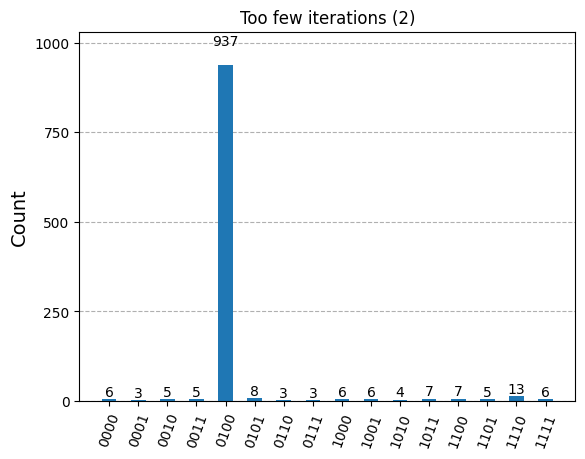

In [10]:
grover_few = QuantumCircuit(n)
for i in range(n):
    grover_few.h(i)
for i in range(r - 1):
    grover_few.append(U, range(n))
    grover_few.append(G, range(n))

grover_few.measure_all()

compiled_few = transpile(grover_few, backend)
counts_few = backend.run(compiled_few, shots=1024).result().get_counts(compiled_few)
plot_histogram(counts_few, title=f"Too few iterations ({r-1})")

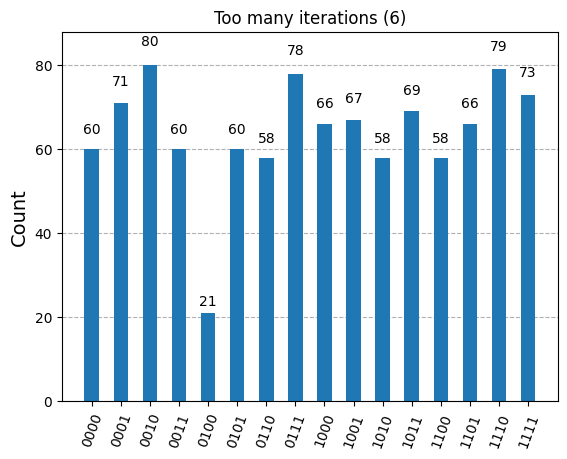

In [11]:
grover_many = QuantumCircuit(n)
for i in range(n):
    grover_many.h(i)
for i in range(r + 3):
    grover_many.append(U, range(n))
    grover_many.append(G, range(n))

grover_many.measure_all()

compiled_many = transpile(grover_many, backend)
counts_many = backend.run(compiled_many, shots=1024).result().get_counts(compiled_many)
plot_histogram(counts_many, title=f"Too many iterations ({r+3})")

Target w=[1, 0, 0, 0]: {'1000': 982, '1011': 3, '0011': 2, '0110': 2, '1100': 5, '1101': 2, '1110': 2, '0111': 3, '0100': 6, '0101': 4, '1001': 4, '0010': 1, '1010': 4, '0000': 1, '0001': 2, '1111': 1}


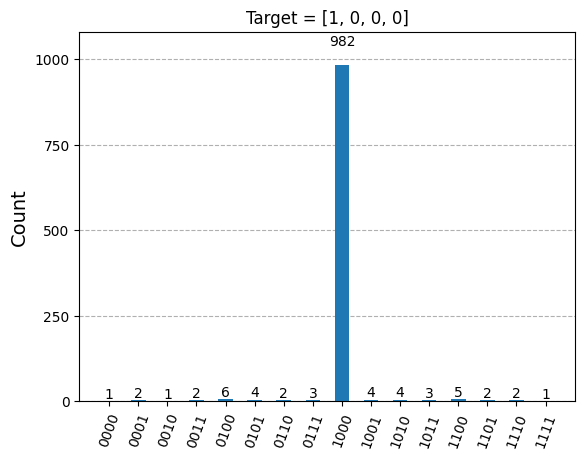

Target w=[0, 0, 1, 0]: {'0010': 984, '0111': 3, '0001': 2, '1111': 4, '0000': 2, '1011': 3, '0100': 5, '1001': 2, '0110': 4, '1101': 4, '0101': 3, '0011': 5, '1100': 1, '1110': 1, '1000': 1}


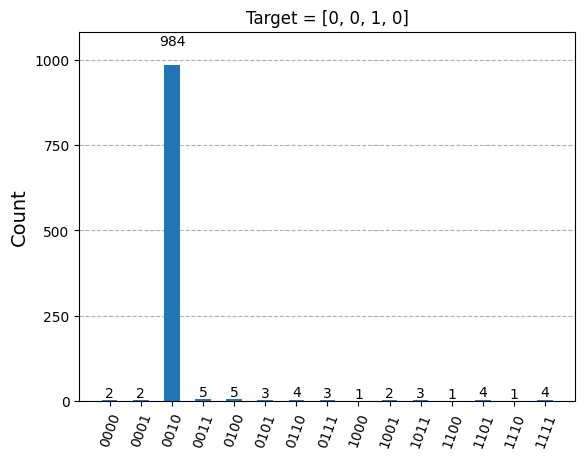

Target w=[1, 1, 0, 0]: {'1100': 982, '1000': 3, '1011': 2, '0100': 3, '1001': 2, '1101': 5, '0011': 3, '0101': 3, '0111': 1, '0110': 1, '0001': 2, '0000': 2, '1010': 5, '0010': 3, '1111': 4, '1110': 3}


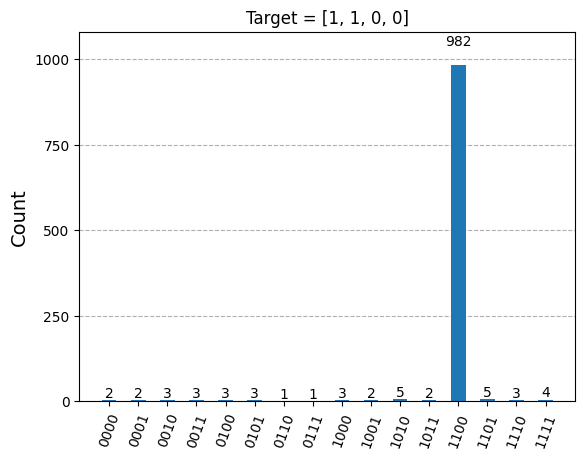

In [12]:
for new_w in [[1,0,0,0], [0,0,1,0], [1,1,0,0]]:
    def f_new(x):
        return 1 if x == new_w else 0

    U_new = Operator(unitary_from_function(f_new, n))
    qc = QuantumCircuit(n)
    for i in range(n):
        qc.h(i)
    for i in range(r):
        qc.append(U_new, range(n))
        qc.append(G, range(n))
    qc.measure_all()

    compiled = transpile(qc, backend)
    counts = backend.run(compiled, shots=1024).result().get_counts(compiled)
    print(f"Target w={new_w}:", counts)
    display(plot_histogram(counts, title=f"Target = {new_w}"))

In [15]:
for n_test in range(2, 11):
    w_test = [0] * n_test
    w_test[0] = 1

    def f_test(x):
        return 1 if x == w_test else 0

    U_test = Operator(unitary_from_function(f_test, n_test))
    G_test = Operator(grover_diffusion(n_test))
    r_test = round(math.pi * math.sqrt(2**n_test) / 4)

    qc = QuantumCircuit(n_test)
    for i in range(n_test):
        qc.h(i)
    for i in range(r_test):
        qc.append(U_test, range(n_test))
        qc.append(G_test, range(n_test))
    qc.measure_all()

    t0 = time.time()
    compiled = transpile(qc, backend)
    counts = backend.run(compiled, shots=512).result().get_counts(compiled)
    elapsed = time.time() - t0

    target_str = format(int("".join(map(str, w_test)), 2), f'0{n_test}b')
    success = counts.get(target_str, 0) / 512 * 100
    print(f"n={n_test:2d}  iters={r_test:2d}  success={success:5.1f}%  time={elapsed:.2f}s")

n= 2  iters= 2  success= 26.2%  time=0.01s
n= 3  iters= 2  success= 93.9%  time=0.01s
n= 4  iters= 3  success= 96.3%  time=0.01s
n= 5  iters= 4  success=100.0%  time=0.01s
n= 6  iters= 6  success= 99.8%  time=0.01s
n= 7  iters= 9  success= 98.6%  time=0.02s
n= 8  iters=13  success= 99.0%  time=0.07s
n= 9  iters=18  success= 99.4%  time=0.26s
n=10  iters=25  success=100.0%  time=0.49s
